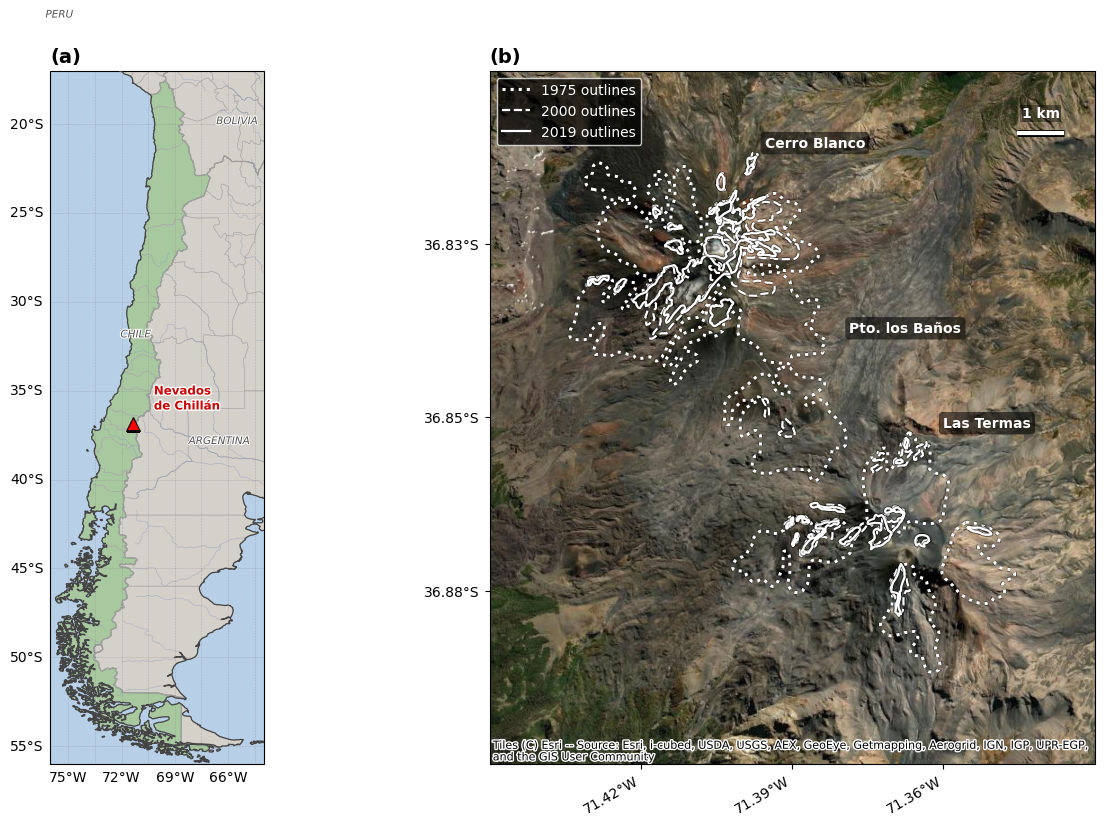

Saved: fig01_study_area.png


In [7]:
# ==============================================================================
# Fig 1: Study area — Chile overview + zoomed complex
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
import numpy as np
import geopandas as gpd
import contextily as ctx
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.patches import Rectangle
import os

SHP = {
    '1975': '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp',
    '2000': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp',
    '2019': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp',
}
FIGURES = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures'
os.makedirs(FIGURES, exist_ok=True)

CERRO_BLANCO_GLACIERS = [
    'CL108101050','CL108105002','CL108101048','CL108116003','CL108116002',
    'CL108116001','CL108116005','CL108116006','CL108116004','CL108101049','CL108105003'
]
LASTERMAS_GLACIERS = [
    'CL108130010','CL108100003','CL108100002','CL108100004','CL108130008',
    'CL108130003','CL108130007','CL108130006','CL108130005','CL108130004',
    'CL108100005','CL108100006','CL108101047','CL108101046','CL108130009'
]
SADDLE_GLACIERS = ['CL108130002','CL108130001']

plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':       12,
    'axes.titlesize':  13,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

NDC_LON, NDC_LAT = -71.38, -36.86

# Load outlines in EPSG:3857
gdf_1975_sa = gpd.read_file(SHP['1975']).to_crs('EPSG:3857')
gdf_2000_sa = gpd.read_file(SHP['2000']).to_crs('EPSG:3857')
gdf_2019_sa = gpd.read_file(SHP['2019']).to_crs('EPSG:3857')
gdf_2019_sa['COD_GLA'] = gdf_2019_sa['COD_GLA'].str.rstrip('@')

# Panel (b) extent from 1975 bounds + padding
_b     = gdf_1975_sa.total_bounds
_pad_x = (_b[2] - _b[0]) * 0.18
_pad_y = (_b[3] - _b[1]) * 0.18
xlim_b = (_b[0] - _pad_x, _b[2] + _pad_x)
ylim_b = (_b[1] - _pad_y, _b[3] + _pad_y)

_tr     = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
lon_min = _tr.transform(xlim_b[0], ylim_b[0])[0]
lon_max = _tr.transform(xlim_b[1], ylim_b[1])[0]
lat_min = _tr.transform(xlim_b[0], ylim_b[0])[1]
lat_max = _tr.transform(xlim_b[1], ylim_b[1])[1]

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
ax_a = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(wspace=0.05)

# ── Panel (a): Chile overview ─────────────────────────────────────────────
ax_a.set_extent([-76, -64, -56, -17], crs=ccrs.PlateCarree())
ax_a.add_feature(cfeature.OCEAN, facecolor='#b8cfe8', zorder=0)

shpfile = shpreader.natural_earth(resolution='10m',
                                   category='cultural',
                                   name='admin_0_countries')
for rec in shpreader.Reader(shpfile).records():
    color = '#a8c8a0' if rec.attributes['NAME'] == 'Chile' else '#d4d0ca'
    ax_a.add_geometries([rec.geometry], ccrs.PlateCarree(),
                         facecolor=color, edgecolor='none', zorder=1)

ax_a.add_feature(cfeature.BORDERS,   linewidth=0.8, edgecolor='#777777', zorder=2)
ax_a.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor='#444444', zorder=3)

provinces = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces', '10m',
    facecolor='none', edgecolor='#aaaaaa', linewidth=0.35)
ax_a.add_feature(provinces, zorder=2)
ax_a.add_feature(cfeature.RIVERS, linewidth=0.4,
                  edgecolor='#8899bb', alpha=0.6, zorder=2)

rect = Rectangle((lon_min, lat_min),
                  lon_max - lon_min, lat_max - lat_min,
                  linewidth=2.0, edgecolor='red', facecolor='#ff000033',
                  transform=ccrs.PlateCarree(), zorder=5)
ax_a.add_patch(rect)

ax_a.plot(NDC_LON, NDC_LAT, marker='^', color='red', markersize=10,
          transform=ccrs.PlateCarree(), zorder=6,
          markeredgecolor='black', markeredgewidth=0.8)
ax_a.text(NDC_LON + 1.2, NDC_LAT + 0.8, 'Nevados\nde Chillán',
          transform=ccrs.PlateCarree(), fontsize=8.5, color='#cc0000',
          fontweight='bold', ha='left',
          path_effects=[pe.withStroke(linewidth=2, foreground='white')])

for name, lon, lat in [
    ('CHILE',     -71.2, -32.0),
    ('ARGENTINA', -66.5, -38.0),
    ('PERU',      -75.5, -14.0),
    ('BOLIVIA',   -65.5, -20.0),
]:
    ax_a.text(lon, lat, name, transform=ccrs.PlateCarree(),
              fontsize=7.5, color='#555555', ha='center', style='italic',
              path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])

gl = ax_a.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                     linewidth=0.4, color='gray', alpha=0.4,
                     linestyle='--', zorder=3)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
ax_a.set_title('(a)', fontsize=14, fontweight='bold', loc='left', pad=6)

# ── Panel (b): Zoomed complex ─────────────────────────────────────────────
ax_b.set_xlim(xlim_b)
ax_b.set_ylim(ylim_b)

try:
    ctx.add_basemap(ax_b, crs='EPSG:3857',
                    source=ctx.providers.Esri.WorldImagery, zoom=13)
except Exception as e:
    print(f'Basemap failed: {e}')

# Outlines
OUTLINE_STYLES_SA = [
    (gdf_1975_sa, 'white', 2.2, ':',  '1975 outlines'),
    (gdf_2000_sa, 'white', 1.6, '--', '2000 outlines'),
    (gdf_2019_sa, 'white', 1.6, '-',  '2019 outlines'),
]
for gdf, color, lw, ls, label in OUTLINE_STYLES_SA:
    plotted = False
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            ax_b.plot(*poly.exterior.xy, color=color, lw=lw, ls=ls,
                      label=label if not plotted else '_nolegend_',
                      path_effects=[pe.withStroke(linewidth=lw+1.2,
                                                   foreground='black',
                                                   alpha=0.5)])
            plotted = True

# Subcomplex labels — no arrows, just text boxes NE of centroid
_w = xlim_b[1] - xlim_b[0]
_h = ylim_b[1] - ylim_b[0]
dx = _w * 0.12
dy = _h * 0.12

for name, ids in [
    ('Cerro Blanco',   CERRO_BLANCO_GLACIERS),
    ('Las Termas',     LASTERMAS_GLACIERS),
    ('Pto. los Baños', SADDLE_GLACIERS),
]:
    gdf_sub = gdf_2000_sa[gdf_2000_sa['COD_GLA'].isin(ids)]
    if len(gdf_sub) == 0:
        continue
    cx = gdf_sub.geometry.centroid.x.mean()
    cy = gdf_sub.geometry.centroid.y.mean()
    ax_b.text(
        cx + dx, cy + dy, name,
        fontsize=10, fontweight='bold', color='white',
        ha='left', va='bottom', zorder=9,
        bbox=dict(facecolor='black', alpha=0.55, pad=2,
                  edgecolor='none', boxstyle='round,pad=0.3'),
    )

# Lat/lon ticks
_to_ll  = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
xtv     = np.linspace(xlim_b[0], xlim_b[1], 5)[1:-1]
ytv     = np.linspace(ylim_b[0], ylim_b[1], 5)[1:-1]
y_mid_b = (ylim_b[0] + ylim_b[1]) / 2
x_mid_b = (xlim_b[0] + xlim_b[1]) / 2
xlons_b = [_to_ll.transform(x, y_mid_b)[0] for x in xtv]
ylats_b = [_to_ll.transform(x_mid_b, y)[1] for y in ytv]
ax_b.set_xticks(xtv)
ax_b.set_yticks(ytv)
ax_b.set_xticklabels([f'{abs(lon):.2f}°{"W" if lon<0 else "E"}'
                       for lon in xlons_b], fontsize=10, rotation=30, ha='right')
ax_b.set_yticklabels([f'{abs(lat):.2f}°{"S" if lat<0 else "N"}'
                       for lat in ylats_b], fontsize=10)
# ax_b.set_xlabel('Longitude', fontsize=12)
# ax_b.set_ylabel('Latitude',  fontsize=12)

# Scale bar — upper right
x1_bar = xlim_b[0] + _w * 0.95
x0_bar = x1_bar - 1000
y_bar  = ylim_b[0] + _h * 0.91
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='black', lw=5, solid_capstyle='butt', zorder=5)
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='white', lw=3, solid_capstyle='butt', zorder=6)
ax_b.text((x0_bar + x1_bar) / 2, y_bar + _h * 0.018,
          '1 km', color='white', ha='center', va='bottom',
          fontsize=10, fontweight='bold', zorder=7,
          bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

# Legend — upper left
handles_b = [
    mlines.Line2D([0],[0], color='white', lw=2.2, ls=':', label='1975 outlines'),
    mlines.Line2D([0],[0], color='white', lw=1.6, ls='--', label='2000 outlines'),
    mlines.Line2D([0],[0], color='white', lw=1.6, ls='-',  label='2019 outlines'),
]
ax_b.legend(handles=handles_b, loc='upper left', fontsize=10,
            framealpha=0.75, facecolor='black',
            edgecolor='white', labelcolor='white')

ax_b.set_title('(b)', fontsize=14, fontweight='bold', loc='left', pad=6)

fig.savefig(os.path.join(FIGURES, 'fig01_study_area.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig01_study_area.png')